In [1]:
%load_ext rpy2.ipython


In [2]:
%%R

install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("readr")

library(sqldf)
library(dplyr)
library(ggplot2)
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cran.rstudio.com/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_3.52.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/sqldf_0.4-12.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmpz1JLqa/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
Content type 'application/x-gzip' length 923509 bytes (901 KB)
downloaded 901 KB


The downloaded source packages are in
	‘/tmp/Rtmpz1JLqa/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.r

In [4]:
from google.colab import files
uploaded = files.upload()


Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving README.txt to README.txt
Saving vehicles.csv to vehicles.csv
Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv


In [5]:
%%R
customers <- read.csv("customers.csv")
drivers <- read.csv("drivers.csv")
vehicles <- read.csv("vehicles.csv")
hubs <- read.csv("hubs.csv")
orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
complaints <- read.csv("complaints.csv")
incidents <- read.csv("incidents.csv")
app_events <- read.csv("app_events.csv")


In [6]:
%%R

library(sqldf)

query1 <- sqldf("
SELECT
    zone_context,
    COUNT(*) AS total_events,
    AVG(api_latency_ms) AS avg_latency
FROM app_events
GROUP BY zone_context
ORDER BY avg_latency DESC
")

print(query1)

   zone_context total_events avg_latency
1       AIRPORT           43    666.6512
2       Airport           44    546.8864
3       Central           24    522.1667
4       CENTRAL           26    515.2692
5           Ctr           43    489.3488
6         north           31    466.8065
7          EAST           40    460.0750
8         North           29    452.5172
9          West           35    443.5429
10        South           43    440.4884
11    Riverside           44    424.9091
12        SOUTH           52    418.5385
13         WEST           59    416.9322
14    RiverSide           43    416.8837
15        NORTH           33    415.8788
16         East           51    414.8235


In [ ]:
%%R

clean_query <- sqldf("
SELECT
    UPPER(zone_context) AS cleaned_zone,
    COUNT(*) AS total_events,
    AVG(api_latency_ms) AS avg_latency
FROM app_events
GROUP BY cleaned_zone
ORDER BY avg_latency DESC
")

print(clean_query)

  cleaned_zone total_events avg_latency
1      AIRPORT           87    606.0805
2      CENTRAL           50    518.5800
3          CTR           43    489.3488
4        NORTH           93    444.2796
5         EAST           91    434.7143
6        SOUTH           95    428.4737
7         WEST           94    426.8404
8    RIVERSIDE           87    420.9425


In [ ]:
%%R

clean_query <- sqldf("
SELECT
    UPPER(zone_context) AS cleaned_zone,
    COUNT(*) AS total_events,
    AVG(api_latency_ms) AS avg_latency
FROM app_events
GROUP BY cleaned_zone
ORDER BY avg_latency DESC
")

print(clean_query)

  cleaned_zone total_events avg_latency
1      AIRPORT           87    606.0805
2      CENTRAL           50    518.5800
3          CTR           43    489.3488
4        NORTH           93    444.2796
5         EAST           91    434.7143
6        SOUTH           95    428.4737
7         WEST           94    426.8404
8    RIVERSIDE           87    420.9425


In [ ]:
%%R

failure_query <- sqldf("
SELECT
    UPPER(zone_context) AS zone,
    COUNT(*) AS failed_events,
    AVG(api_latency_ms) AS avg_latency
FROM app_events
WHERE success_flag = 0
GROUP BY UPPER(zone_context)
ORDER BY failed_events DESC
")

print(failure_query)

       zone failed_events avg_latency
1 RIVERSIDE             8    374.0000
2     NORTH             7    485.0000
3      WEST             5    411.8000
4     SOUTH             4    503.2500
5   CENTRAL             4    879.7500
6   AIRPORT             4    329.2500
7      EAST             3    374.6667
8       CTR             3    461.3333


In [ ]:
%%R

event_failure_query <- sqldf("
SELECT
    event_type,
    COUNT(*) AS failed_events,
    AVG(api_latency_ms) AS avg_latency
FROM app_events
WHERE success_flag = 0
GROUP BY event_type
ORDER BY failed_events DESC
")

print(event_failure_query)

      event_type failed_events avg_latency
1  payment_retry            19    425.2632
2 chat_escalated            19    511.7368


In [ ]:
%%R

failure_percentage_query <- sqldf("
SELECT
    UPPER(zone_context) AS zone,
    COUNT(*) AS total_events,
    SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) AS failed_events,

    ROUND(
        (SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) * 100.0) / COUNT(*),
        2
    ) AS failure_percentage

FROM app_events

GROUP BY UPPER(zone_context)

ORDER BY failure_percentage DESC
")

print(failure_percentage_query)

       zone total_events failed_events failure_percentage
1 RIVERSIDE           87             8               9.20
2   CENTRAL           50             4               8.00
3     NORTH           93             7               7.53
4       CTR           43             3               6.98
5      WEST           94             5               5.32
6   AIRPORT           87             4               4.60
7     SOUTH           95             4               4.21
8      EAST           91             3               3.30


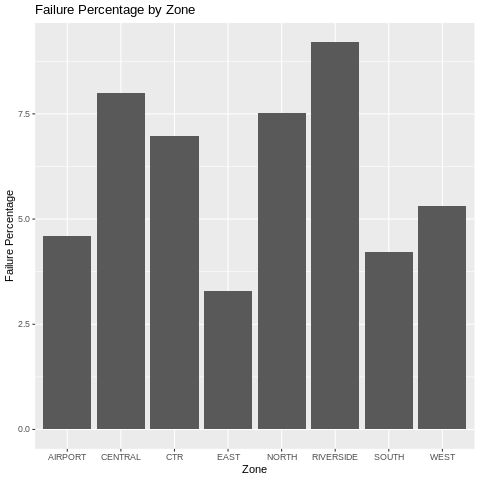

In [ ]:
%%R

library(ggplot2)

ggplot(failure_percentage_query,
       aes(x = zone, y = failure_percentage)) +
  geom_bar(stat = "identity") +
  ggtitle("Failure Percentage by Zone") +
  xlab("Zone") +
  ylab("Failure Percentage")

In [ ]:
%%R

latency_failure_query <- sqldf("
SELECT
    CASE
        WHEN api_latency_ms < 300 THEN 'LOW_LATENCY'
        WHEN api_latency_ms BETWEEN 300 AND 600 THEN 'MEDIUM_LATENCY'
        ELSE 'HIGH_LATENCY'
    END AS latency_group,

    COUNT(*) AS total_events,

    SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) AS failed_events,

    ROUND(
        (SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) * 100.0) / COUNT(*),
        2
    ) AS failure_percentage

FROM app_events

GROUP BY latency_group

ORDER BY failure_percentage DESC
")

print(latency_failure_query)

   latency_group total_events failed_events failure_percentage
1    LOW_LATENCY          182            12               6.59
2 MEDIUM_LATENCY          289            18               6.23
3   HIGH_LATENCY          169             8               4.73


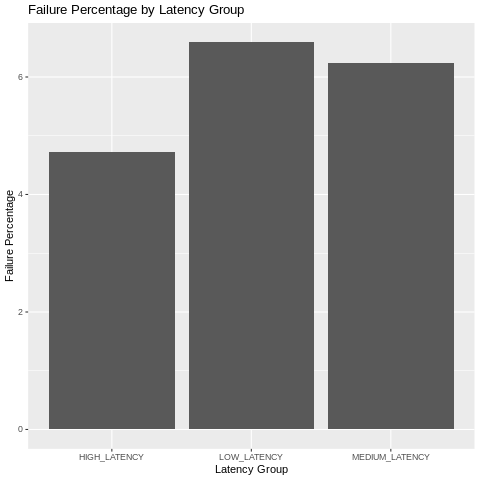

In [ ]:
%%R

ggplot(latency_failure_query,
       aes(x = latency_group,
           y = failure_percentage)) +
  geom_bar(stat = "identity") +
  ggtitle("Failure Percentage by Latency Group") +
  xlab("Latency Group") +
  ylab("Failure Percentage")

In [ ]:
%%R

list.files()

 [1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "README.txt"          "sample_data"         "vehicles.csv"       


In [ ]:
%%R

list(
  complaints = colnames(complaints),
  customers = colnames(customers),
  deliveries = colnames(deliveries),
  drivers = colnames(drivers),
  hubs = colnames(hubs),
  incidents = colnames(incidents),
  orders = colnames(orders),
  vehicles = colnames(vehicles)
)

$complaints
 [1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

$customers
[1] "customer_id"          "age"                  "home_zone"           
[4] "customer_type"        "signup_date"          "loyalty_score"       
[7] "app_engagement_score" "preferred_channel"    "account_status"      

$deliveries
 [1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"          

$drivers
[1] "driver_id"        "base_zone"        "

In [ ]:
%%R

complaint_delivery_query <- sqldf("

SELECT
    c.complaint_type,
    d.delivery_status,
    COUNT(*) AS total_cases,
    AVG(d.customer_rating_post_delivery) AS avg_rating

FROM complaints c

INNER JOIN deliveries d
ON c.order_id = d.order_id

GROUP BY c.complaint_type, d.delivery_status

ORDER BY total_cases DESC

")

print(complaint_delivery_query)

      complaint_type delivery_status total_cases avg_rating
1              Delay          OnTime          44   4.302955
2    DriverBehaviour          OnTime          29   4.222414
3           AppIssue          OnTime          25   4.246800
4       MissedPickup          OnTime          25   4.407500
5              Delay         Delayed          19   3.082222
6       MissedPickup         Delayed          11   3.492727
7  SupportExperience          OnTime          11   4.173636
8              Delay          Failed          10   3.359000
9             Damage          OnTime           8   4.396250
10      MissedPickup          Failed           8   3.601250
11          AppIssue         Delayed           7   3.246667
12           Billing          OnTime           7   4.385714
13          AppIssue          Failed           5   3.204000
14   DriverBehaviour         Delayed           5   3.806000
15   DriverBehaviour          Failed           4   2.885000
16 SupportExperience          Failed    

In [ ]:
%%R

driver_analysis_query <- sqldf("

SELECT
    dr.driver_id,
    dr.driver_rating,
    dr.training_score,
    COUNT(i.incident_id) AS total_incidents,
    AVG(d.customer_rating_post_delivery) AS avg_customer_rating

FROM drivers dr

LEFT JOIN deliveries d
ON dr.driver_id = d.driver_id

LEFT JOIN incidents i
ON d.delivery_id = i.delivery_id

GROUP BY dr.driver_id

ORDER BY total_incidents DESC

")

print(driver_analysis_query)

    driver_id driver_rating training_score total_incidents avg_customer_rating
1        D039          4.06           86.1               7            4.335000
2        D087          4.43           73.3               6            3.825000
3        D146          4.36             NA               5            3.855556
4        D132          4.20           77.6               5            3.566667
5        D026          3.15           84.9               5            4.079091
6        D004          4.75           88.9               5            3.510000
7        D154          4.35           67.0               4            3.878750
8        D140          3.92           80.1               4            3.075000
9        D119          3.55           56.0               4            4.066923
10       D108          4.33           70.6               4            4.411818
11       D094          4.48           60.8               4            3.706667
12       D088          4.17           84.3          

In [ ]:
%%R

vehicle_analysis_query <- sqldf("

SELECT
    v.maintenance_status,
    v.vehicle_type,
    COUNT(d.delivery_id) AS total_deliveries,
    AVG(d.customer_rating_post_delivery) AS avg_customer_rating,
    AVG(v.battery_health_pct) AS avg_battery_health,
    AVG(d.fuel_or_charge_cost) AS avg_operating_cost

FROM vehicles v

LEFT JOIN deliveries d
ON v.vehicle_id = d.vehicle_id

GROUP BY v.maintenance_status, v.vehicle_type

ORDER BY avg_operating_cost DESC

")

print(vehicle_analysis_query)

   maintenance_status vehicle_type total_deliveries avg_customer_rating
1           Scheduled       Diesel                9            3.751111
2              Active     CargoVan              117            3.920259
3            InRepair       Diesel               55            3.659273
4            InRepair       Hybrid               71            3.780571
5              Active           EV              214            3.950660
6           Scheduled           EV               65            3.969844
7            InRepair           EV               60            3.638276
8           Scheduled       Hybrid               42            3.881220
9              Active       Hybrid              131            3.944308
10           InRepair     CargoVan               68            3.456716
11             Active       Diesel               80            4.028158
12          Scheduled     CargoVan               38            3.965000
   avg_battery_health avg_operating_cost
1            81.33333  

In [ ]:
%%R

hub_analysis_query <- sqldf("

SELECT
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(d.delivery_id) AS total_deliveries,
    AVG(d.customer_rating_post_delivery) AS avg_customer_rating,
    AVG(d.manual_route_override_count) AS avg_route_overrides

FROM hubs h

LEFT JOIN deliveries d
ON h.hub_id = d.hub_id

GROUP BY h.hub_name, h.zone, h.hub_type

ORDER BY avg_route_overrides DESC

")

print(hub_analysis_query)

        hub_name      zone  hub_type total_deliveries avg_customer_rating
1  Midtown Relay   Central  Charging              128            3.884560
2  Riverside Hub Riverside Warehouse              115            3.881858
3 North Exchange     North  Dispatch              136            3.840593
4   Central Core   Central   Control              115            3.669558
5     South Link     South  Dispatch              106            3.950952
6    Airport Hub   Airport  Dispatch              104            3.882136
7      East Dock      East Warehouse              119            3.895862
8      West Gate      West  Dispatch              127            3.915476
  avg_route_overrides
1           1.1093750
2           1.0521739
3           1.0294118
4           0.9478261
5           0.9150943
6           0.9134615
7           0.8907563
8           0.8740157


In [ ]:
%%R

delivery_trend_query <- sqldf("

SELECT
    substr(dispatch_time, 1, 7) AS delivery_month,
    COUNT(*) AS total_deliveries,
    AVG(customer_rating_post_delivery) AS avg_customer_rating

FROM deliveries

GROUP BY delivery_month

ORDER BY delivery_month

")

print(delivery_trend_query)

   delivery_month total_deliveries avg_customer_rating
1         2024-01               45            3.975455
2         2024-02               46            3.962609
3         2024-03               52            3.908200
4         2024-04               34            3.790882
5         2024-05               35            3.918857
6         2024-06               43            3.774419
7         2024-07               33            4.007576
8         2024-08               44            4.083023
9         2024-09               41            3.868537
10        2024-10               32            3.670313
11        2024-11               50            3.917959
12        2024-12               47            3.925333
13        2025-01               46            3.895870
14        2025-02               35            3.576286
15        2025-03               31            3.893667
16        2025-04               44            3.780233
17        2025-05               36            3.745429
18        

In [ ]:
%%R

high_incident_drivers_query <- sqldf("

SELECT
    dr.driver_id,
    COUNT(i.incident_id) AS total_incidents,
    AVG(d.customer_rating_post_delivery) AS avg_rating

FROM drivers dr

LEFT JOIN deliveries d
ON dr.driver_id = d.driver_id

LEFT JOIN incidents i
ON d.delivery_id = i.delivery_id

GROUP BY dr.driver_id

HAVING total_incidents >= 3

ORDER BY total_incidents DESC

")

print(high_incident_drivers_query)

   driver_id total_incidents avg_rating
1       D039               7   4.335000
2       D087               6   3.825000
3       D146               5   3.855556
4       D132               5   3.566667
5       D026               5   4.079091
6       D004               5   3.510000
7       D154               4   3.878750
8       D140               4   3.075000
9       D119               4   4.066923
10      D108               4   4.411818
11      D094               4   3.706667
12      D088               4   3.876000
13      D084               4   3.774000
14      D069               4   3.830000
15      D037               4   4.071250
16      D032               4   4.346667
17      D002               4   3.210000
18      D168               3   3.461667
19      D167               3   4.347500
20      D164               3   4.341250
21      D158               3   3.816667
22      D156               3   3.547500
23      D135               3   4.043636
24      D133               3   3.423333


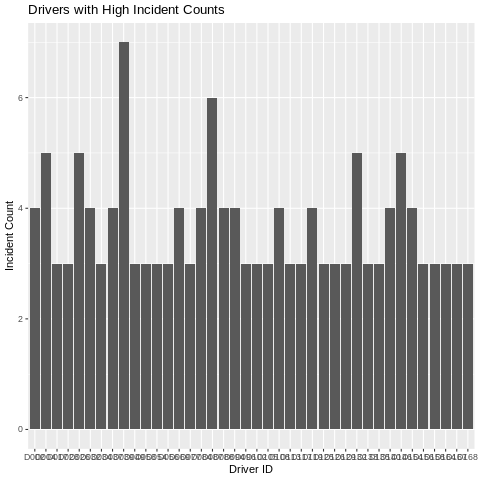

In [ ]:
%%R

ggplot(high_incident_drivers_query,
       aes(x = driver_id,
           y = total_incidents)) +
  geom_bar(stat = "identity") +
  ggtitle("Drivers with High Incident Counts") +
  xlab("Driver ID") +
  ylab("Incident Count")

In [ ]:
%%R

summary(deliveries[, c(
  "route_distance_km",
  "manual_route_override_count",
  "customer_rating_post_delivery",
  "fuel_or_charge_cost"
)])

 route_distance_km manual_route_override_count customer_rating_post_delivery
 Min.   : 1.200    Min.   :0.0000              Min.   :1.000                
 1st Qu.: 9.135    1st Qu.:0.0000              1st Qu.:3.360                
 Median :12.840    Median :1.0000              Median :4.040                
 Mean   :13.909    Mean   :0.9695              Mean   :3.865                
 3rd Qu.:16.835    3rd Qu.:2.0000              3rd Qu.:4.550                
 Max.   :41.940    Max.   :7.0000              Max.   :5.000                
                                               NAs    :14                   
 fuel_or_charge_cost
 Min.   : 2.500     
 1st Qu.: 9.925     
 Median :12.645     
 Mean   :12.841     
 3rd Qu.:15.697     
 Max.   :29.430     
                    


In [ ]:
%%R

correlation_data <- deliveries[, c(
  "route_distance_km",
  "manual_route_override_count",
  "customer_rating_post_delivery",
  "fuel_or_charge_cost"
)]

cor(correlation_data, use = "complete.obs")

                              route_distance_km manual_route_override_count
route_distance_km                    1.00000000                  0.19938470
manual_route_override_count          0.19938470                  1.00000000
customer_rating_post_delivery        0.02852525                 -0.05990295
fuel_or_charge_cost                  0.52655156                  0.09882420
                              customer_rating_post_delivery fuel_or_charge_cost
route_distance_km                                0.02852525          0.52655156
manual_route_override_count                     -0.05990295          0.09882420
customer_rating_post_delivery                    1.00000000         -0.05906232
fuel_or_charge_cost                             -0.05906232          1.00000000


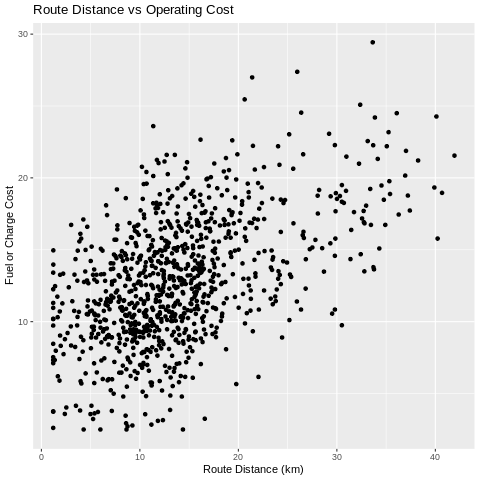

In [ ]:
%%R

ggplot(deliveries,
       aes(x = route_distance_km,
           y = fuel_or_charge_cost)) +
  geom_point() +
  ggtitle("Route Distance vs Operating Cost") +
  xlab("Route Distance (km)") +
  ylab("Fuel or Charge Cost")

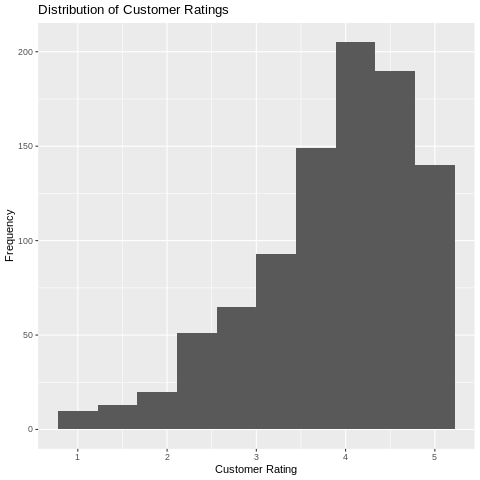

In [ ]:
%%R

ggplot(deliveries,
       aes(x = customer_rating_post_delivery)) +
  geom_histogram(bins = 10) +
  ggtitle("Distribution of Customer Ratings") +
  xlab("Customer Rating") +
  ylab("Frequency")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
app_events = pd.read_csv("app_events.csv")
complaints = pd.read_csv("complaints.csv")
customers = pd.read_csv("customers.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers = pd.read_csv("drivers.csv")
hubs = pd.read_csv("hubs.csv")
incidents = pd.read_csv("incidents.csv")
orders = pd.read_csv("orders.csv")
vehicles = pd.read_csv("vehicles.csv")

In [ ]:
print(drivers.isnull().sum())

driver_id           0
base_zone           0
employment_type     0
years_experience    0
training_score      7
driver_rating       0
shift_preference    0
active_flag         0
dtype: int64


In [ ]:
high_cost = deliveries.sort_values(
    by="fuel_or_charge_cost",
    ascending=False
)

print(high_cost[[
    "delivery_id",
    "vehicle_id",
    "fuel_or_charge_cost",
    "route_distance_km"
]].head(10))

    delivery_id vehicle_id  fuel_or_charge_cost  route_distance_km
896     DL00897       V043                29.43              33.64
143     DL00144       V016                27.38              25.98
712     DL00713       V039                26.99              21.40
663     DL00664       V027                25.46              20.64
118     DL00119       V037                25.09              32.37
51      DL00052       V020                24.54              26.38
286     DL00287       V099                24.50              36.08
805     DL00806       V108                24.27              40.11
89      DL00090       V065                24.20              33.86
372     DL00373       V081                23.60              11.36


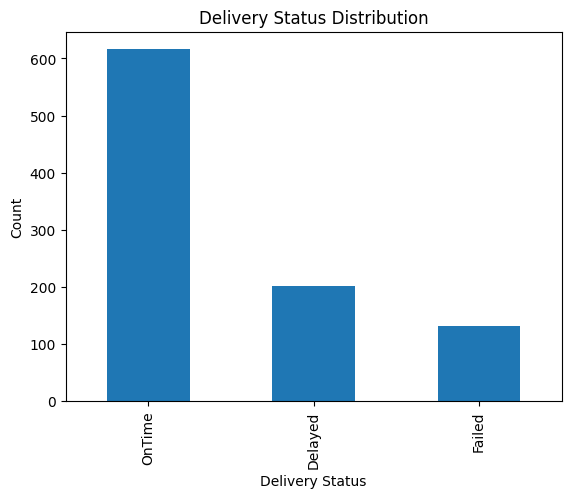

In [ ]:
delivery_status_counts.plot(kind="bar")

plt.xlabel("Delivery Status")
plt.ylabel("Count")
plt.title("Delivery Status Distribution")

plt.show()

In [ ]:
delivery_status_counts = deliveries["delivery_status"].value_counts()

print(delivery_status_counts)

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


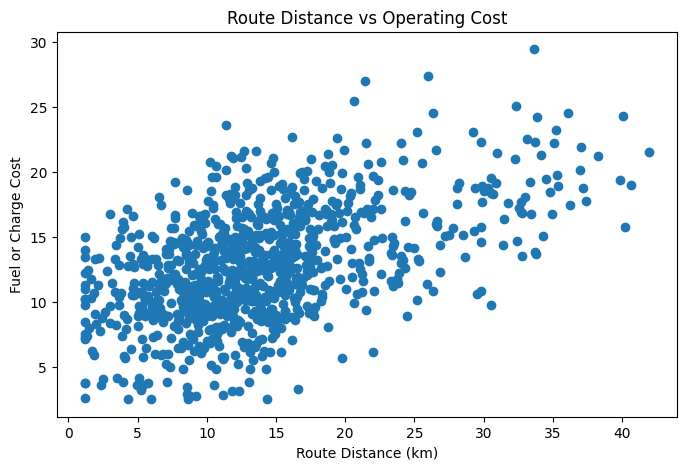

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    deliveries["route_distance_km"],
    deliveries["fuel_or_charge_cost"]
)

plt.xlabel("Route Distance (km)")
plt.ylabel("Fuel or Charge Cost")
plt.title("Route Distance vs Operating Cost")

plt.show()

In [ ]:
complaint_severity = complaints["severity"].value_counts()

print(complaint_severity)

severity
Medium    172
High       77
Low        71
Name: count, dtype: int64


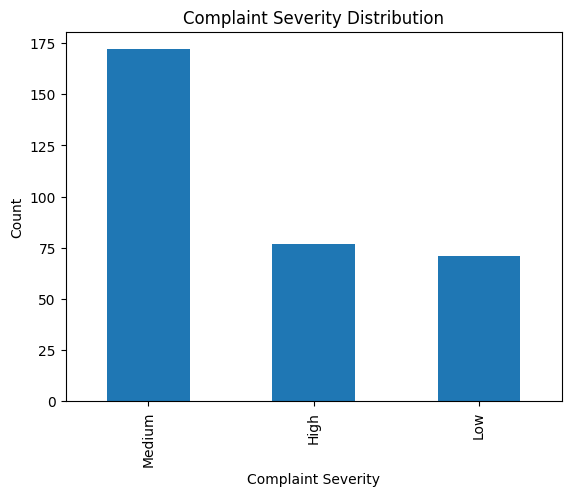

In [ ]:
complaint_severity.plot(kind="bar")

plt.xlabel("Complaint Severity")
plt.ylabel("Count")
plt.title("Complaint Severity Distribution")

plt.show()

In [ ]:
delivery_driver_merge = pd.merge(
    deliveries,
    drivers,
    on="driver_id"
)

print(delivery_driver_merge.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

In [ ]:
incident_counts = incidents.groupby("delivery_id").size()

print(incident_counts.head())

delivery_id
DL00001    1
DL00009    2
DL00011    1
DL00013    1
DL00014    1
dtype: int64


In [ ]:
vehicle_performance = deliveries.merge(
    vehicles,
    on="vehicle_id"
)

print(vehicle_performance[[
    "vehicle_type",
    "maintenance_status",
    "fuel_or_charge_cost"
]].head())

  vehicle_type maintenance_status  fuel_or_charge_cost
0           EV             Active                12.05
1       Diesel             Active                13.41
2       Diesel             Active                 8.51
3       Hybrid             Active                13.62
4           EV           InRepair                 9.22


In [ ]:
vehicle_costs = vehicle_performance.groupby(
    "vehicle_type"
)["fuel_or_charge_cost"].mean()

print(vehicle_costs)

vehicle_type
CargoVan    12.842422
Diesel      12.853056
EV          12.925988
Hybrid      12.715656
Name: fuel_or_charge_cost, dtype: float64


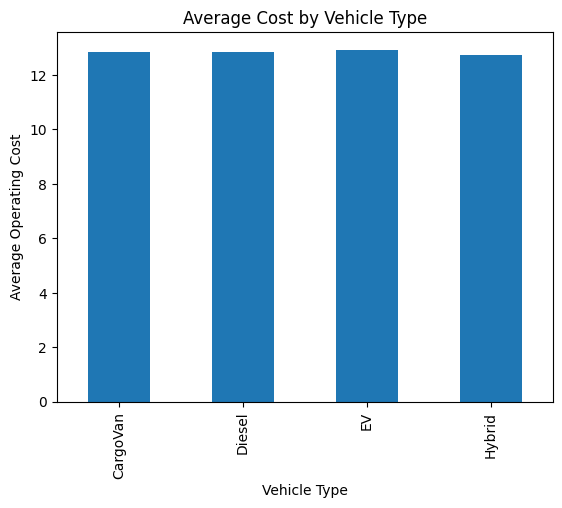

In [ ]:
vehicle_costs.plot(kind="bar")

plt.xlabel("Vehicle Type")
plt.ylabel("Average Operating Cost")
plt.title("Average Cost by Vehicle Type")

plt.show()

In [ ]:
hub_merge = deliveries.merge(
    hubs,
    on="hub_id"
)

hub_performance = hub_merge.groupby(
    "hub_name"
)["customer_rating_post_delivery"].mean()

print(hub_performance)

hub_name
Airport Hub       3.882136
Central Core      3.669558
East Dock         3.895862
Midtown Relay     3.884560
North Exchange    3.840593
Riverside Hub     3.881858
South Link        3.950952
West Gate         3.915476
Name: customer_rating_post_delivery, dtype: float64


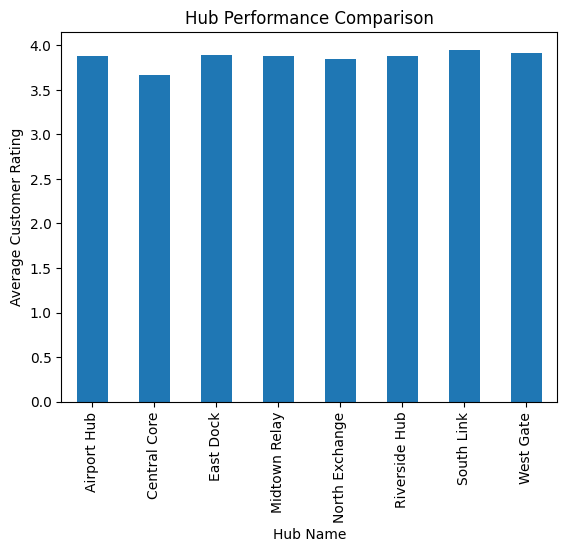

In [ ]:
hub_performance.plot(kind="bar")

plt.xlabel("Hub Name")
plt.ylabel("Average Customer Rating")
plt.title("Hub Performance Comparison")

plt.show()

In [ ]:
override_analysis = deliveries.groupby(
    "delivery_status"
)["manual_route_override_count"].mean()

print(override_analysis)

delivery_status
Delayed    1.074257
Failed     1.037879
OnTime     0.920455
Name: manual_route_override_count, dtype: float64


In [ ]:
correlation = deliveries[[
    "route_distance_km",
    "manual_route_override_count",
    "fuel_or_charge_cost",
    "customer_rating_post_delivery"
]].corr()

print(correlation)

                               route_distance_km  manual_route_override_count  \
route_distance_km                       1.000000                     0.202296   
manual_route_override_count             0.202296                     1.000000   
fuel_or_charge_cost                     0.524194                     0.098690   
customer_rating_post_delivery           0.028525                    -0.059903   

                               fuel_or_charge_cost  \
route_distance_km                         0.524194   
manual_route_override_count               0.098690   
fuel_or_charge_cost                       1.000000   
customer_rating_post_delivery            -0.059062   

                               customer_rating_post_delivery  
route_distance_km                                   0.028525  
manual_route_override_count                        -0.059903  
fuel_or_charge_cost                                -0.059062  
customer_rating_post_delivery                       1.000000  
